# Segmentation

A segmenter splits an image into masks. Paired with a feature map, the masks turn noisy patch
features into one clean feature per object. This page runs `MobileSAMSegmentation` on one
committed frame and pools MaskCLIP features inside its masks. SAM3 (text prompts), INSID3
(in-context, from reference masks) and SkyWater (sky masks for the mesh stage) share the same
`BaseSegmentation` interface.

In [1]:
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np

from collab_splats.semantics import (
    MaskCLIPExtractor,
    MobileSAMSegmentation,
    aggregate_masked_features,
)
from collab_splats.utils.image import open_image, resize_image
from collab_splats.utils.visualization import overlay_masks, pca_to_rgb

%run ../tutorial.py

# Image panels without pixel axes
BARE = {"frame_on": False, "xticks": [], "yticks": []}

# One committed frame at 1024 px; SAM's auto mode upsamples every candidate mask to full size
image = open_image(QUERY_IMAGE)
image = resize_image(image, 1024)
image = image.convert("RGB")
frame = np.asarray(image)

## 1. Two strategies

`MobileSAMSegmentation` has two ways to prompt SAM:

- `object`: a YOLOv8 detector finds boxes, then SAM draws one mask per box. Every detection
  gets a mask, down to small litter on the ground.
- `auto`: SAM is prompted with a dense grid of points. Besides objects, this catches large
  regions such as the ground.

Both return an `(N, H, W)` bool mask stack and the raw SAM results.

object 53 masks


auto 39 masks


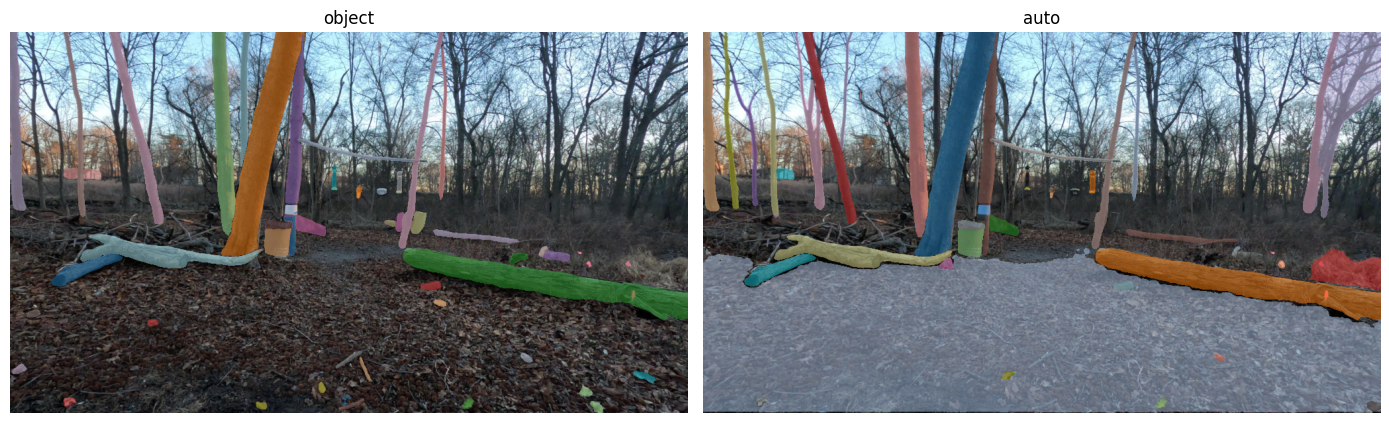

In [2]:
masks = {}

# One segmentation per strategy
for strategy in ("object", "auto"):
    # torch.hub, the SAM checkpoint loader and YOLO print as they go; keep the page to the counts
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        segmenter = MobileSAMSegmentation(strategy=strategy, device="cuda")
        masks[strategy], _ = segmenter.segment(frame)

    print(strategy, len(masks[strategy]), "masks")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=BARE)

# Each mask drawn in its own color
for ax, strategy in zip(axes, masks):
    overlay = overlay_masks(frame, masks[strategy])
    ax.imshow(overlay)
    ax.set_title(strategy)

plt.tight_layout()

Compare the two: `object` masks the trunks, logs and scattered small items but leaves the
ground bare, while `auto` covers the ground with one large mask. Neither masks the sky.

## 2. Mask-pooled features

`aggregate_masked_features` averages the patch features inside each mask and paints that mean
back over the mask's pixels, which gives a feature map that is constant within each object.
Where masks overlap, the later mask wins; pixels outside every mask are zero. Pooling here stays
on the patch grid, since `pca_to_rgb` resizes to the frame itself.

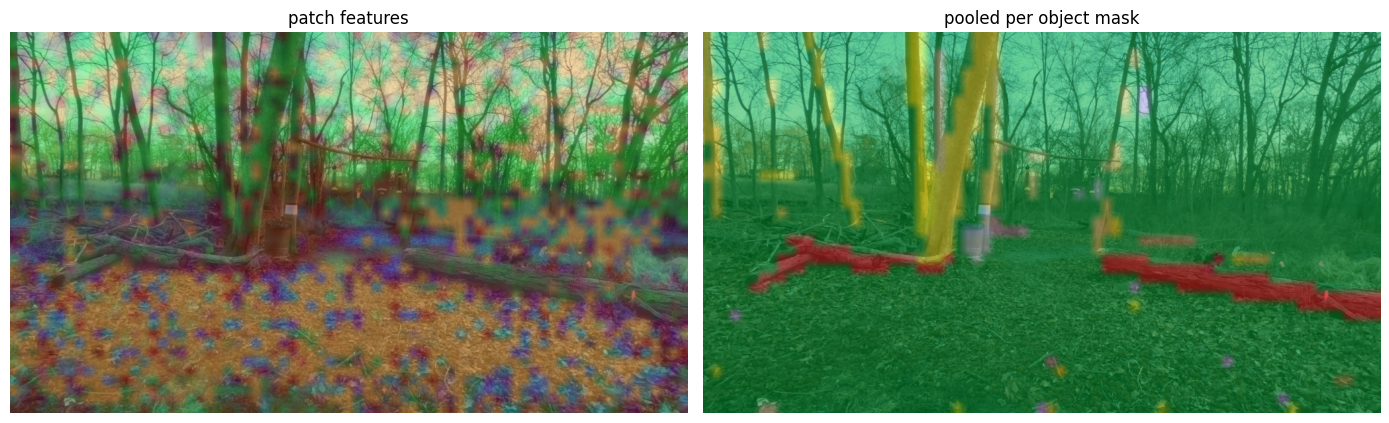

In [3]:
features = MaskCLIPExtractor().forward([frame])[0]
patch_grid = tuple(features.shape[1:])

# Pool the object masks on the patch grid
pooled = aggregate_masked_features(
    features,
    masks["object"],
    resolution=patch_grid,
    final_resolution=patch_grid,
)

raw_rgb = pca_to_rgb(features, frame)
pooled_rgb = pca_to_rgb(pooled, frame)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=BARE)
axes[0].imshow(raw_rgb)
axes[0].set_title("patch features")
axes[1].imshow(pooled_rgb)
axes[1].set_title("pooled per object mask")

plt.tight_layout()

On the right, each detected object should be one flat tint over the image, while the patch
features on the left vary from patch to patch across the same object.

## In a pipeline run

The pipeline uses segmentation in the mesh stage. With `mesh.mask_sky` on, the SkyWater
segmenter marks sky pixels in every keyframe and their depth is zeroed before TSDF fusion, so
the sky does not fuse into a backdrop or seed floaters.

```yaml
mesh:
  mask_sky: true
```